# EEG_13b — DHSLP Subject-Specific LOSO

**Domanda di ricerca**: le iperedge learnable di DHSLP aiutano nel setting subject-specific,
dove la variabilità inter-soggetto (eps²=0.85) non è un problema?

- **Modello**: DHSLP (da EEG_13) — `H_k = softmax(feat_k @ E^T / sqrt(d))`
- **Setting**: Subject-Specific LOSO (come EEG_12)
- **Split**: test=ultima sessione, val=penultima, train=resto
- **Config**: N_EDGES=16, D_MODEL=64 (best da ablation EEG_13)
- **Confronto atteso**: EEG_12 (W-HGNN) best P007=34.4%, EEG_09b best P031=31.8%

Differenza chiave da EEG_12: **nessuna H_pruned in input** — DHSLP apprende la topologia
direttamente dal task di classificazione, non da PCC/wPLI pre-calcolati.

In [ ]:
import json, logging, re, traceback
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import balanced_accuracy_score, recall_score
from tqdm.auto import tqdm
import wandb

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg13b')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents) if (p/'.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
CKPT_DIR = project_root / 'models' / 'eeg13b'; CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ---- CONFIG ----
N_CHANNELS   = 61
N_SAMPLES    = 384
N_CLASSES    = 4
CLUSTER_SCHEME = 'concr4'

# DHSLP iperparametri — best config da ablation EEG_13 (E16_d64 = 25.68%)
K_WINDOWS  = 8
N_EDGES    = 16
D_MODEL    = 64
HIDDEN     = 128
N_LAYERS   = 2
DROPOUT    = 0.5    # aumentato da 0.3 — S-Spec ha ~330 trial/sogg., overfitting severo

# Training — S-Spec: regolarizzazione più forte rispetto a S-Indep
LR               = 1e-3
WEIGHT_DECAY     = 1e-2   # aumentato da 1e-4 — contrasta memorizzazione training set
GRAD_CLIP        = 1.0    # gradient clipping per stabilità
BATCH_SIZE       = 32
MAX_EPOCHS       = 80
PATIENCE         = 15
USE_INSTANCE_NORM = True
LABEL_SMOOTHING  = 0.1

# Data augmentation — solo su training set
USE_AUGMENTATION = True
AUG_NOISE_STD    = 0.05   # rumore gaussiano (std relativa)
AUG_AMP_RANGE    = (0.85, 1.15)  # scaling ampiezza
AUG_SHIFT_MAX    = 15     # shift temporale circolare (campioni)
AUG_MASK_LEN     = 20     # mascheramento temporale (campioni)

# Sorgente dati: qualsiasi directory hypergraphs_pruned_* va bene.
# Tutti e 5 i directory (pcc/abs_pcc/im_pcc/wpli/plv) contengono x e y identici —
# differisce solo H_pruned, che DHSLP ignora completamente (la apprende via E learnable).
# abs_pcc è scelto arbitrariamente come path di accesso ai file .pt.
DATA_METRIC = 'abs_pcc'

WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'

T_WIN = N_SAMPLES // K_WINDOWS

_PAT = re.compile(r'^P(\d+)_S(\d+)$')
label2cluster = {int(k): int(v) for k,v in json.loads(
    (project_root/'configs'/'label_schemes'/'labelid2cluster_concr4.json').read_text()).items()}

# Indicizza tutti i trial per soggetto e sessione
HG_ROOT = project_root / 'data' / f'hypergraphs_pruned_{DATA_METRIC}'
subj_sess = defaultdict(lambda: defaultdict(list))
for p in sorted(HG_ROOT.rglob('trial_*.pt')):
    m = _PAT.match(p.parent.name)
    if m:
        subj_sess[int(m.group(1))][int(m.group(2))].append(p)

ALL_SUBJ = sorted(subj_sess.keys())
log.info(f'HG_ROOT: {HG_ROOT}')
log.info(f'Soggetti trovati: {len(ALL_SUBJ)}  T_WIN={T_WIN}  K={K_WINDOWS}')
log.info(f'N_EDGES={N_EDGES}  D_MODEL={D_MODEL}  (best config da EEG_13 ablation)')
log.info(f'DROPOUT={DROPOUT}  WEIGHT_DECAY={WEIGHT_DECAY}  GRAD_CLIP={GRAD_CLIP}  (fix overfitting S-Spec)')
log.info(f'USE_AUGMENTATION={USE_AUGMENTATION}')

## §2 — Dataset LOSO (solo x e y — H non caricata)

In [ ]:
def _augment_eeg(x: torch.Tensor) -> torch.Tensor:
    """Augmentazione EEG in-place (clone già fatto dal caller). Solo su training."""
    x = x.clone()
    if torch.rand(1) < 0.5:
        x = x + torch.randn_like(x) * AUG_NOISE_STD
    if torch.rand(1) < 0.5:
        x = x * torch.empty(1).uniform_(*AUG_AMP_RANGE)
    if torch.rand(1) < 0.5:
        shift = torch.randint(-AUG_SHIFT_MAX, AUG_SHIFT_MAX + 1, (1,)).item()
        x = torch.roll(x, shift, dims=1)
    if torch.rand(1) < 0.3:
        T = x.shape[1]
        start = torch.randint(0, max(1, T - AUG_MASK_LEN), (1,)).item()
        x[:, start:start + AUG_MASK_LEN] = 0.0
    if torch.rand(1) < 0.2:
        ch = torch.randint(0, x.shape[0], (1,)).item()
        x[ch] = 0.0
    return x


class EEGRawDatasetSS(Dataset):
    """
    Carica x (61,384) e y dai file .pt.
    H_pruned ignorata: DHSLP costruisce H internamente.
    """
    def __init__(self, paths_and_labels, use_instance_norm=True, augment=False):
        self.items = paths_and_labels
        self.use_instance_norm = use_instance_norm
        self.augment = augment

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        p, label = self.items[idx]
        d = torch.load(p, weights_only=False)
        x = d['x'].float()   # (61, 384)
        if self.use_instance_norm:
            x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)
        if self.augment:
            x = _augment_eeg(x)
        return x, torch.tensor(label, dtype=torch.long)


def _collect(subj_id, sess_list):
    items = []
    for s in sess_list:
        for p in subj_sess[subj_id][s]:
            d = torch.load(p, weights_only=False)
            y_word = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
            c = label2cluster.get(y_word)
            if c is not None:
                items.append((p, c))
    return items


def make_loso_loaders(subj_id):
    """LOSO: test=ultima sessione, val=penultima, train=resto."""
    sids = sorted(subj_sess[subj_id].keys())
    if len(sids) < 2:
        return None
    test_sess  = sids[-1]
    val_sess   = sids[-2]
    train_sess = [s for s in sids if s not in (test_sess, val_sess)]

    tr_items = _collect(subj_id, train_sess)
    va_items = _collect(subj_id, [val_sess])
    te_items = _collect(subj_id, [test_sess])
    if not tr_items or not te_items:
        return None

    # WeightedRandomSampler: bilancia le 4 classi nel train
    tr_labels = np.array([it[1] for it in tr_items])
    counts    = np.bincount(tr_labels, minlength=N_CLASSES)
    sample_w  = torch.tensor(1.0 / counts[tr_labels], dtype=torch.float)
    sampler   = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

    kw = dict(num_workers=0, pin_memory=False)
    return (
        DataLoader(EEGRawDatasetSS(tr_items, USE_INSTANCE_NORM, augment=USE_AUGMENTATION),
                   BATCH_SIZE, sampler=sampler, **kw),
        DataLoader(EEGRawDatasetSS(va_items, USE_INSTANCE_NORM, augment=False),
                   BATCH_SIZE, shuffle=False, **kw),
        DataLoader(EEGRawDatasetSS(te_items, USE_INSTANCE_NORM, augment=False),
                   BATCH_SIZE, shuffle=False, **kw),
    )

## §3 — Modello: DHSLP

Identico a EEG_13. H_k costruita dinamicamente per ogni finestra e trial:
```
feat_k = Linear(x_k) + pos_enc        → (B, 61, d)
H_k    = softmax(feat_k @ E^T / √d)   → (B, 61, n_edges)
out_k  = HGNNConv(feat_k, H_k).mean   → (B, hidden)
z      = mean(out_1..K) → Linear → logits
```
Differenza da W-HGNN (EEG_12): **E è learnable**, non viene passata H dal disco.

In [3]:
class HGNNConv(nn.Module):
    """HGNN layer (Feng et al. 2019) — batched bmm."""
    def __init__(self, in_ch, out_ch, bias=True):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_ch, out_ch))
        self.bias   = nn.Parameter(torch.zeros(out_ch)) if bias else None
        nn.init.xavier_uniform_(self.weight)

    def forward(self, X, H):
        # X: (B,N,C)  H: (B,N,E) — soft, dinamica
        d_v = H.sum(dim=2).clamp(min=1e-6)
        d_e = H.sum(dim=1).clamp(min=1e-6)
        Dv  = (1.0 / d_v.sqrt()).unsqueeze(-1)
        De  = (1.0 / d_e).unsqueeze(1)
        out = Dv * (X @ self.weight)
        out = torch.bmm(H.transpose(1, 2), out)
        out = De.transpose(1, 2) * out
        out = torch.bmm(H, out)
        out = Dv * out
        if self.bias is not None: out = out + self.bias
        return out


class DHSLP(nn.Module):
    """
    Dynamic Hypergraph Spectral Learning with Positional encoding.
    Li et al. 2025. Input: solo x (B, 61, 384) — nessuna H in input.
    """
    def __init__(self, n_nodes=N_CHANNELS, T_win=T_WIN, K=K_WINDOWS,
                 n_edges=N_EDGES, d_model=D_MODEL, hidden=HIDDEN,
                 n_classes=N_CLASSES, n_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.K, self.T_win, self.d_model = K, T_win, d_model

        # Learnable iperedge embeddings — cuore di DHSLP
        self.E = nn.Parameter(torch.randn(n_edges, d_model) * 0.01)
        # Encoding posizionale per elettrodo (learnable)
        self.pos_enc = nn.Parameter(torch.randn(n_nodes, d_model) * 0.01)

        self.node_proj = nn.Sequential(
            nn.Linear(T_win, d_model),
            nn.LayerNorm(d_model),
            nn.ELU(),
        )
        dims = [d_model] + [hidden] * n_layers
        self.convs = nn.ModuleList([HGNNConv(dims[i], dims[i+1]) for i in range(n_layers)])
        self.bns   = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Linear(hidden, n_classes)

    def build_dynamic_H(self, feat):
        # feat: (B, N, d)  →  H: (B, N, n_edges)
        scores = torch.matmul(feat, self.E.T) / (self.d_model ** 0.5)
        return torch.softmax(scores, dim=2)

    def forward(self, x):
        B, N, T = x.shape
        outs = []
        for k in range(self.K):
            x_k  = x[:, :, k*self.T_win:(k+1)*self.T_win]   # (B,N,T_win)
            feat = self.node_proj(x_k) + self.pos_enc        # (B,N,d)
            H_k  = self.build_dynamic_H(feat)                # (B,N,n_edges)
            out  = feat
            for conv, bn in zip(self.convs, self.bns):
                out = conv(out, H_k)
                out = bn(out.reshape(B*N, -1)).reshape(B, N, -1)
                out = F.relu(out)
                out = self.drop(out)
            outs.append(out.mean(dim=1))   # (B, hidden)
        return self.clf(torch.stack(outs, dim=1).mean(dim=1))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log.info(f'device: {device}')
_m = DHSLP()
n_p = sum(p.numel() for p in _m.parameters() if p.requires_grad)
log.info(f'DHSLP OK — {n_p:,} parametri  K={K_WINDOWS} n_edges={N_EDGES} d_model={D_MODEL}')
del _m

22:58:33 INFO     device: cuda
22:58:33 INFO     DHSLP OK — 34,052 parametri  K=8 n_edges=16 d_model=64


## §4 — Train / Eval

In [ ]:
_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)


def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, all_labels, all_preds = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss   = _criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_labels.extend(y.cpu().numpy())
            all_preds.extend(logits.argmax(1).cpu().numpy())
    bacc = balanced_accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), bacc, np.array(all_labels), np.array(all_preds)


def train_subject(subj_id, tr_l, va_l, te_l):
    run_name = f'eeg13b_DHSLP_P{subj_id:03d}_{CLUSTER_SCHEME}'
    cfg = dict(
        notebook='EEG_13b', model='DHSLP_SS', subject=f'P{subj_id:03d}',
        n_classes=N_CLASSES, cluster_scheme=CLUSTER_SCHEME,
        k_windows=K_WINDOWS, t_win=T_WIN,
        n_edges=N_EDGES, d_model=D_MODEL,
        hidden=HIDDEN, n_layers=N_LAYERS, dropout=DROPOUT,
        lr=LR, weight_decay=WEIGHT_DECAY, grad_clip=GRAD_CLIP,
        batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS,
        use_instance_norm=USE_INSTANCE_NORM,
        label_smoothing=LABEL_SMOOTHING,
        weighted_sampler=True,
        use_augmentation=USE_AUGMENTATION,
        dynamic_H='learned_softmax',
        topology_source='end_to_end',
        n_train=len(tr_l.dataset),
    )
    run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                     name=run_name, config=cfg, reinit='finish_previous',
                     settings=wandb.Settings(start_method='thread'))

    model = DHSLP().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MAX_EPOCHS)
    best_val, best_state, patience_cnt = 0.0, None, 0

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_b, _, _ = run_epoch(model, tr_l, opt)
        va_loss, va_b, _, _ = run_epoch(model, va_l)
        sched.step()
        run.log({'train/loss': tr_loss, 'train/bacc': tr_b,
                 'val/loss': va_loss,   'val/bacc': va_b,
                 'train_val_gap': tr_b - va_b,
                 'epoch': epoch})
        if va_b > best_val:
            best_val = va_b
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            log.info(f'  P{subj_id:03d} early stop @ epoch {epoch}'); break

    model.load_state_dict(best_state)
    _, te_b, te_lbl, te_pred = run_epoch(model, te_l)

    # Checkpoint per soggetto
    ckpt = CKPT_DIR / f'P{subj_id:03d}.pt'
    torch.save({'state_dict': best_state, 'val_bacc': best_val, 'test_bacc': te_b,
                'labels': te_lbl, 'preds': te_pred}, ckpt)

    run.summary['val_bacc']  = best_val
    run.summary['test_bacc'] = te_b
    run.log({'confusion_matrix': wandb.plot.confusion_matrix(
        preds=te_pred.tolist(), y_true=te_lbl.tolist(),
        class_names=['CONCR', 'AZIONE', 'STATO', 'ASTRATTO'])})
    run.finish()
    log.info(f'  P{subj_id:03d}: val={best_val:.4f}  test={te_b:.4f}')
    return {'val_bacc': best_val, 'test_bacc': te_b, 'labels': te_lbl, 'preds': te_pred}

## §5 — Loop su Tutti i Soggetti

In [5]:
SUBJECT_RESULTS = {}

for sid in tqdm(ALL_SUBJ, desc='DHSLP S-Spec'):
    loaders = make_loso_loaders(sid)
    if loaders is None:
        log.warning(f'P{sid:03d}: skip (sessioni insufficienti)')
        continue
    tr_l, va_l, te_l = loaders
    log.info(f'P{sid:03d}: train={len(tr_l.dataset)} val={len(va_l.dataset)} test={len(te_l.dataset)}')
    try:
        SUBJECT_RESULTS[sid] = train_subject(sid, tr_l, va_l, te_l)
    except Exception as e:
        log.error(f'P{sid:03d}: {e}\n{traceback.format_exc()}')

log.info(f'\n=== DONE: {len(SUBJECT_RESULTS)}/{len(ALL_SUBJ)} soggetti ===')

DHSLP S-Spec:   0%|          | 0/74 [00:00<?, ?it/s]

22:58:34 INFO     P000: train=330 val=110 test=110
wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/daniele_u/.netrc.
wandb: Currently logged in as: uras-daniele22 (uras-daniele22-politecnico-di-milano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


22:58:52 INFO       P000 early stop @ epoch 22


epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇██
train/bacc,▁▃▃▃▃▄▅▅▆▆▆▆▇▇▇▇▇▇████
train/loss,██▇▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▁▁▁
val/bacc,▁▂▇█▆▇█▆▇▇▅▇▂▄▃▅▆▅▂▂█▅
val/loss,▁▁▁▁▁▁▁▂▁▁▁▂▅▃▄▆▄▆█▄▄▄
epoch,22
test_bacc,0.26293
train/bacc,0.95401
train/loss,0.59339
val/bacc,0.24128
val/loss,1.61453


22:58:56 INFO       P000: val=0.2797  test=0.2629
22:58:56 INFO     P001: train=330 val=110 test=110


...

epoch,▁▁▂▂▃▃▄▄▅▅▅▆▆▇▇██
train/bacc,▁▂▃▄▄▄▅▆▅▇▇▇▇▇███
train/loss,██▇▇▇▆▆▅▅▄▃▃▃▂▂▁▁
val/bacc,██▂▂▃▅▂▄▆▄▁▃▇▆▄▃▅
val/loss,▃▂▁▂▂▃▃▃▃▃▄▆▇▅▇▆█
epoch,17
test_bacc,0.20271
train/bacc,0.9377
train/loss,0.65928
val/bacc,0.24266
val/loss,1.61514


23:25:52 INFO       P071: val=0.2808  test=0.2027
23:25:53 INFO     P072: train=330 val=110 test=110


23:26:06 INFO       P072 early stop @ epoch 16


epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
train/bacc,▁▃▃▄▅▅▅▆▆▆▇▇▇▇██
train/loss,█▇▇▇▇▆▆▅▅▄▃▃▂▂▁▁
val/bacc,█▆█▄▅▆▆▂▂▂▂▂▃▁▄▁
val/loss,▂▁▁▂▃▃▃▃▃▄▅▇█▆▇█
epoch,16
test_bacc,0.15726
train/bacc,0.90757
train/loss,0.75006
val/bacc,0.19886
val/loss,1.56029


23:26:09 INFO       P072: val=0.3154  test=0.1573
23:26:09 WARNING  P073: skip (sessioni insufficienti)
23:26:09 INFO     
=== DONE: 73/74 soggetti ===


## §6 — Ricarica da Checkpoint + Ranking

In [6]:
if not SUBJECT_RESULTS:
    log.info('Ricarico da checkpoint...')
    for ckpt in sorted(CKPT_DIR.glob('P*.pt')):
        sid = int(ckpt.stem[1:])
        d = torch.load(ckpt, weights_only=False)
        SUBJECT_RESULTS[sid] = {k: d[k] for k in ('val_bacc', 'test_bacc', 'labels', 'preds')}
    log.info(f'Ricaricati {len(SUBJECT_RESULTS)} soggetti')

if not SUBJECT_RESULTS:
    print('[INFO] Nessun risultato — esegui prima §5.')
else:
    def top2_bacc(labels, preds, n_classes=N_CLASSES):
        recalls = recall_score(labels, preds, average=None, zero_division=0,
                               labels=list(range(n_classes)))
        top2_cls = np.argsort(recalls)[-2:]
        mask = np.isin(labels, top2_cls)
        if mask.sum() == 0: return np.nan, top2_cls.tolist()
        return balanced_accuracy_score(labels[mask], preds[mask]), top2_cls.tolist()

    rows = []
    for sid, res in SUBJECT_RESULTS.items():
        lbl = np.array(res['labels']); pred = np.array(res['preds'])
        t2, _ = top2_bacc(lbl, pred)
        rows.append({
            'Subject':   f'P{sid:03d}',
            'Test bAcc': round(res['test_bacc'], 4),
            'Top2 bAcc': round(t2, 4) if not np.isnan(t2) else np.nan,
        })

    df_top1 = pd.DataFrame(rows).sort_values('Test bAcc', ascending=False).reset_index(drop=True)
    df_top2 = pd.DataFrame(rows).sort_values('Top2 bAcc', ascending=False).reset_index(drop=True)
    df_top1.to_csv(FIG_DIR / 'eeg13b_subject_ranking.csv', index=False)

    print('Top-10 by Test bAcc (DHSLP S-Spec):')
    print(df_top1.head(10).to_string(index=False))
    print(f'\nMediana: {df_top1["Test bAcc"].median():.4f}  '
          f'Mean: {df_top1["Test bAcc"].mean():.4f}  '
          f'Max: {df_top1["Test bAcc"].max():.4f}')
    print(f'% sopra chance: {(df_top1["Test bAcc"] > 0.25).mean()*100:.1f}%')

/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924

Top-10 by Test bAcc (DHSLP S-Spec):
Subject  Test bAcc  Top2 bAcc
   P068     0.3636     0.4495
   P015     0.3474     0.5000
   P026     0.3262     0.3981
   P001     0.3195     0.4484
   P051     0.3172     0.3757
   P007     0.3168     0.5595
   P065     0.3122     0.3837
   P038     0.3057     0.4764
   P053     0.3041     0.4600
   P047     0.3021     0.3704

Mediana: 0.2466  Mean: 0.2493  Max: 0.3636
% sopra chance: 45.2%


/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924

## §7 — Bar Chart Ranking

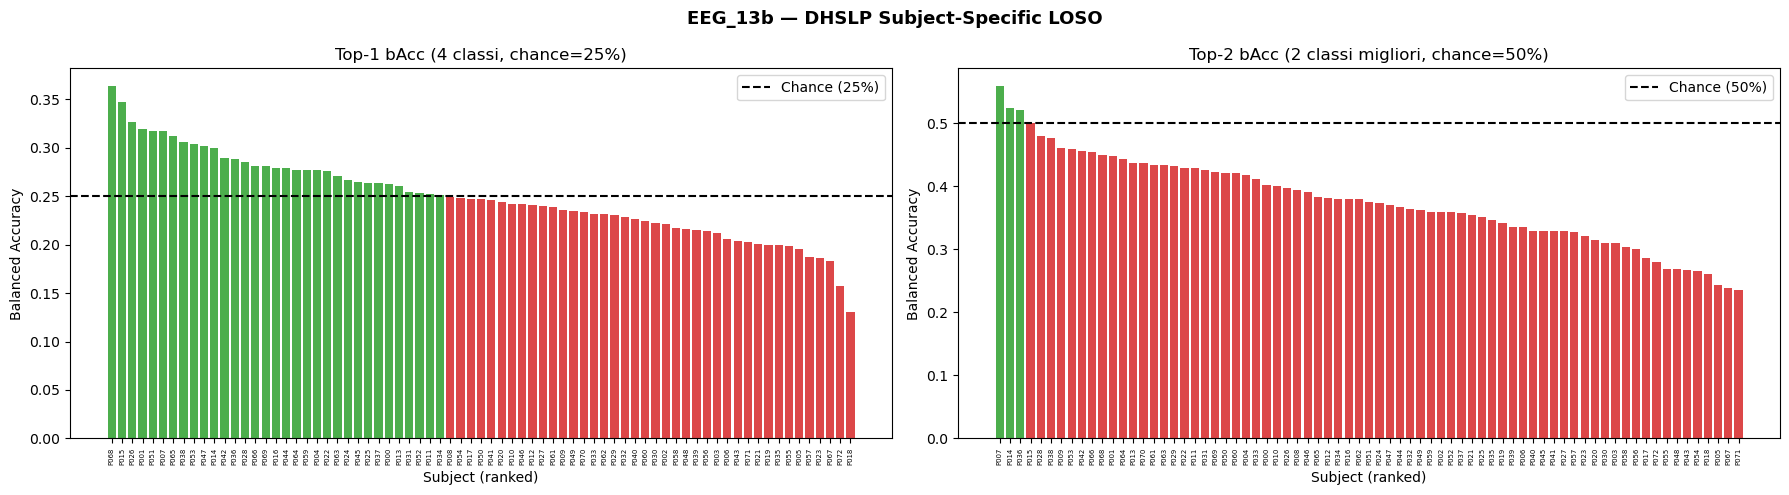

In [7]:
if 'df_top1' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    chance = 1 / N_CLASSES

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle('EEG_13b — DHSLP Subject-Specific LOSO', fontsize=13, fontweight='bold')

    for ax, df, col, ch, title in [
        (ax1, df_top1, 'Test bAcc', chance,  f'Top-1 bAcc (4 classi, chance={chance:.0%})'),
        (ax2, df_top2, 'Top2 bAcc', 0.5,    'Top-2 bAcc (2 classi migliori, chance=50%)'),
    ]:
        vals   = df[col].fillna(0).values
        colors = ['#2ca02c' if v > ch else '#d62728' for v in vals]
        ax.bar(range(len(vals)), vals, color=colors, alpha=0.85, edgecolor='none')
        ax.axhline(ch, color='black', ls='--', lw=1.5, label=f'Chance ({ch:.0%})')
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels(df['Subject'], rotation=90, fontsize=5)
        ax.set_xlabel('Subject (ranked)'); ax.set_ylabel('Balanced Accuracy')
        ax.set_title(title); ax.legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg13b_dhslp_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()

## §8 — Confronto: DHSLP vs W-HGNN (EEG_12) vs HGNN Statico (EEG_09b)

Domanda chiave: **le iperedge apprese aiutano in S-Spec rispetto a H_pruned fissa?**

- Delta positivo → DHSLP supera W-HGNN: le HE learnable catturano topologie per-soggetto migliori
- Delta ≈ 0 → la topologia non è il bottleneck neanche in S-Spec
- Delta negativo → H_pruned da PCC/wPLI è più informativa di HE learnable con pochi dati

Top-10 confronto:
Subject  DHSLP (EEG_13b)  W-HGNN (EEG_12)  Δ vs EEG_12  HGNN (EEG_09b)  Δ vs EEG_09b
   P068           0.3636           0.2256       0.1380          0.2317        0.1319
   P015           0.3474           0.2286       0.1188          0.2868        0.0606
   P026           0.3262           0.2945       0.0317          0.2235        0.1027
   P001           0.3195           0.2225       0.0970          0.2700        0.0495
   P051           0.3172           0.3328      -0.0156          0.2792        0.0380
   P007           0.3168           0.3444      -0.0276          0.2500        0.0668
   P065           0.3122           0.2413       0.0709          0.2593        0.0529
   P038           0.3057           0.2311       0.0746          0.2128        0.0929
   P053           0.3041           0.2321       0.0720          0.2244        0.0797
   P047           0.3021           0.2173       0.0848          0.2443        0.0578

Delta medio DHSLP - W-HGNN:  +0.0036
Delta med

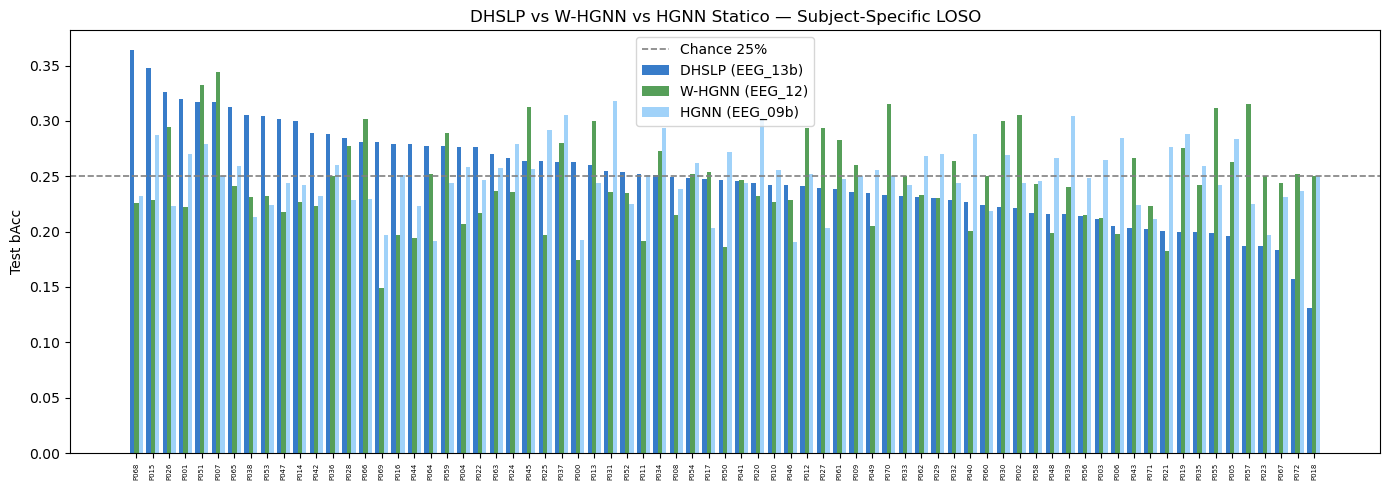

In [8]:
if 'df_top1' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    df_cmp = df_top1[['Subject', 'Test bAcc']].rename(columns={'Test bAcc': 'DHSLP (EEG_13b)'})

    # Carica EEG_12 (W-HGNN S-Spec)
    csv12 = FIG_DIR / 'eeg12_subject_ranking.csv'
    if csv12.exists():
        df12 = pd.read_csv(csv12)[['Subject', 'Test bAcc']].rename(columns={'Test bAcc': 'W-HGNN (EEG_12)'})
        df_cmp = df_cmp.merge(df12, on='Subject', how='left')
        df_cmp['Δ vs EEG_12'] = (df_cmp['DHSLP (EEG_13b)'] - df_cmp['W-HGNN (EEG_12)']).round(4)

    # Carica EEG_09b (HGNN S-Spec baseline)
    csv09b = FIG_DIR / 'eeg09b_subject_ranking.csv'
    if csv09b.exists():
        df09b = pd.read_csv(csv09b)[['Subject', 'Test bAcc']].rename(columns={'Test bAcc': 'HGNN (EEG_09b)'})
        df_cmp = df_cmp.merge(df09b, on='Subject', how='left')
        df_cmp['Δ vs EEG_09b'] = (df_cmp['DHSLP (EEG_13b)'] - df_cmp['HGNN (EEG_09b)']).round(4)

    df_cmp = df_cmp.sort_values('DHSLP (EEG_13b)', ascending=False).reset_index(drop=True)
    df_cmp.to_csv(FIG_DIR / 'eeg13b_comparison.csv', index=False)

    print('Top-10 confronto:')
    print(df_cmp.head(10).to_string(index=False))
    if 'Δ vs EEG_12' in df_cmp:
        print(f'\nDelta medio DHSLP - W-HGNN:  {df_cmp["Δ vs EEG_12"].mean():+.4f}')
    if 'Δ vs EEG_09b' in df_cmp:
        print(f'Delta medio DHSLP - HGNN:    {df_cmp["Δ vs EEG_09b"].mean():+.4f}')

    # Plot confronto a barre affiancate
    models = ['DHSLP (EEG_13b)', 'W-HGNN (EEG_12)', 'HGNN (EEG_09b)']
    colors_map = {'DHSLP (EEG_13b)': '#1565C0', 'W-HGNN (EEG_12)': '#388E3C', 'HGNN (EEG_09b)': '#90CAF9'}
    available = [m for m in models if m in df_cmp.columns]
    n_models  = len(available)
    width     = 0.8 / n_models
    x         = np.arange(len(df_cmp))

    fig, ax = plt.subplots(figsize=(max(14, len(df_cmp)*0.18), 5))
    for i, m in enumerate(available):
        offset = (i - n_models/2 + 0.5) * width
        ax.bar(x + offset, df_cmp[m].fillna(0), width, label=m,
               color=colors_map[m], alpha=0.85, edgecolor='none')
    ax.axhline(1/N_CLASSES, color='gray', ls='--', lw=1.2, label='Chance 25%')
    ax.set_xticks(x)
    ax.set_xticklabels(df_cmp['Subject'], rotation=90, fontsize=5)
    ax.set_ylabel('Test bAcc')
    ax.set_title('DHSLP vs W-HGNN vs HGNN Statico — Subject-Specific LOSO')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg13b_vs_eeg12_vs_09b.png', dpi=150, bbox_inches='tight')
    plt.show()

## §9 — Confusion Matrix Top-5

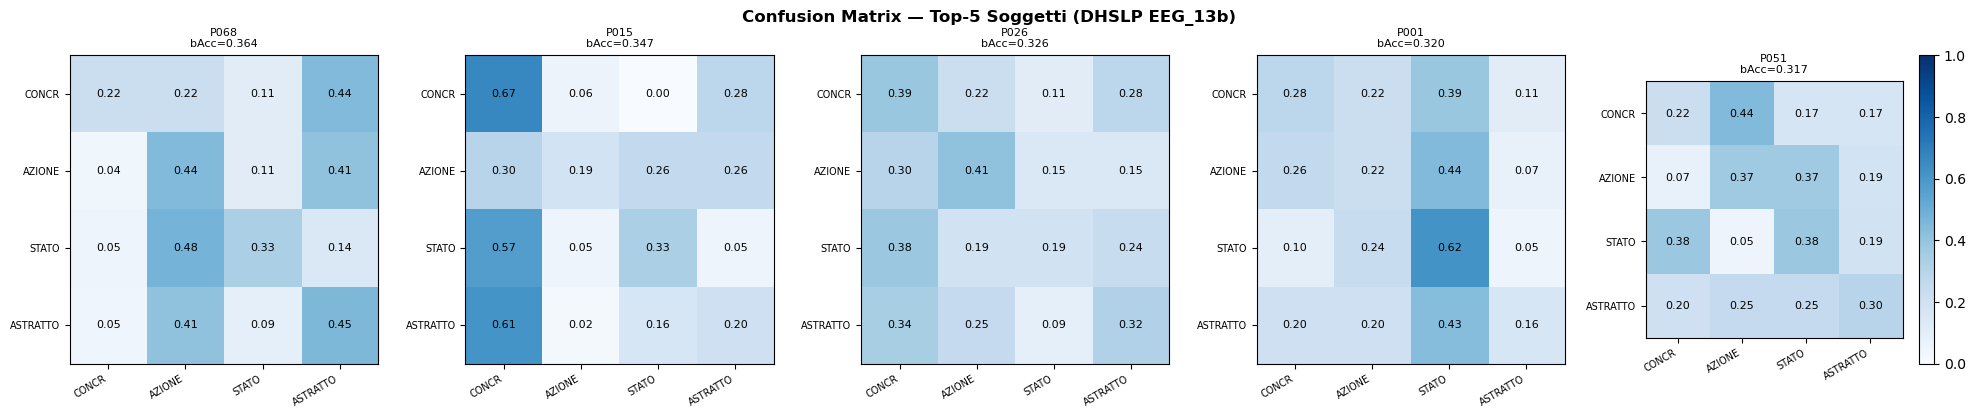

In [9]:
if 'df_top1' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    from sklearn.metrics import confusion_matrix
    CLASS_NAMES = ['CONCR', 'AZIONE', 'STATO', 'ASTRATTO']

    top5 = df_top1.head(5)
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle('Confusion Matrix — Top-5 Soggetti (DHSLP EEG_13b)', fontsize=12, fontweight='bold')

    for ax, (_, row) in zip(axes, top5.iterrows()):
        sid = int(row['Subject'][1:])
        res = SUBJECT_RESULTS.get(sid)
        if res is None or 'labels' not in res:
            ax.set_title(row['Subject']); ax.axis('off'); continue
        lbl  = np.array(res['labels']); pred = np.array(res['preds'])
        cm   = confusion_matrix(lbl, pred, labels=list(range(N_CLASSES)), normalize='true')
        im   = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(range(N_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, fontsize=7, rotation=30, ha='right')
        ax.set_yticks(range(N_CLASSES))
        ax.set_yticklabels(CLASS_NAMES, fontsize=7)
        for i in range(N_CLASSES):
            for j in range(N_CLASSES):
                ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center', fontsize=8)
        ax.set_title(f'{row["Subject"]}\nbAcc={row["Test bAcc"]:.3f}', fontsize=8)

    plt.colorbar(im, ax=axes[-1])
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg13b_cm_top5.png', dpi=150, bbox_inches='tight')
    plt.show()

## §11 — Full Retrain con Best HPs da Optuna (200 epoch, patience 70)

Usa i best HPs trovati in §10. 200 epoch max, patience 70, log `train_val_gap` per epoca in W&B.

In [ ]:
import json as _json

# Carica best HPs (da Optuna §10 o da disco)
_hp_path = project_root / 'models' / 'eeg13b' / 'optuna_best_hps.json'
if 'BEST_HPS' not in dir():
    if _hp_path.exists():
        _data = _json.loads(_hp_path.read_text())
        BEST_HPS = _data['best_params']
        log.info(f'HPs caricati da disco: {BEST_HPS}')
    else:
        log.warning('BEST_HPS non trovato — usa HPs default da §1')
        BEST_HPS = {
            'dropout': DROPOUT, 'weight_decay': WEIGHT_DECAY, 'lr': LR,
            'n_edges': N_EDGES, 'd_model': D_MODEL, 'hidden': HIDDEN,
            'mixup_alpha': MIXUP_ALPHA, 'label_smoothing': LABEL_SMOOTHING,
            'k_windows': K_WINDOWS,
        }

OPTUNA_MAX_EPOCHS_FULL = 200
OPTUNA_PATIENCE_FULL   = 70
CKPT_DIR_OPT = project_root / 'models' / 'eeg13b_optuna'; CKPT_DIR_OPT.mkdir(parents=True, exist_ok=True)

log.info(f'Full retrain con: {BEST_HPS}')
log.info(f'MAX_EPOCHS={OPTUNA_MAX_EPOCHS_FULL}  PATIENCE={OPTUNA_PATIENCE_FULL}')

def train_subject_optuna(subj_id, tr_l, va_l, te_l, hps):
    k_win = hps['k_windows']
    t_win = N_SAMPLES // k_win

    model = DHSLP(
        n_nodes=N_CHANNELS, T_win=t_win, K=k_win,
        n_edges=hps['n_edges'], d_model=hps['d_model'],
        hidden=hps['hidden'], n_classes=N_CLASSES,
        n_layers=N_LAYERS, dropout=hps['dropout']
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=hps['lr'], weight_decay=hps['weight_decay']
    )
    criterion = nn.CrossEntropyLoss(label_smoothing=hps['label_smoothing'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=OPTUNA_MAX_EPOCHS_FULL)
    alpha_local = hps['mixup_alpha']

    def _epoch(loader, train=False):
        model.train() if train else model.eval()
        total_loss, all_lbl, all_pred = 0.0, [], []
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                if train and alpha_local > 0:
                    lam = float(__import__('numpy').random.beta(alpha_local, alpha_local))
                    idx = torch.randperm(len(x), device=x.device)
                    x_mix = lam * x + (1 - lam) * x[idx]
                    logits = model(x_mix)
                    loss = lam * criterion(logits, y) + (1 - lam) * criterion(logits, y[idx])
                else:
                    logits = model(x)
                    loss = criterion(logits, y)
                if train:
                    optimizer.zero_grad(); loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    optimizer.step()
                total_loss += loss.item() * len(y)
                all_lbl.extend(y.cpu().tolist()); all_pred.extend(logits.argmax(1).cpu().tolist())
        return total_loss / max(len(all_lbl), 1), balanced_accuracy_score(all_lbl, all_pred)

    run = wandb.init(
        project=WANDB_PROJECT, entity=WANDB_ENTITY,
        name=f'eeg13b_v2_P{subj_id:03d}',
        config={**hps, 'notebook': 'EEG_13b_optuna', 'subject': subj_id,
                'max_epochs': OPTUNA_MAX_EPOCHS_FULL, 'patience': OPTUNA_PATIENCE_FULL,
                'n_classes': N_CLASSES, 'cluster_scheme': CLUSTER_SCHEME},
        reinit=True
    )

    best_val, best_state, no_improve = 0.25, None, 0
    for ep in range(OPTUNA_MAX_EPOCHS_FULL):
        tr_loss, tr_b = _epoch(tr_l, train=True)
        va_loss, va_b = _epoch(va_l, train=False)
        scheduler.step()
        gap = tr_b - va_b
        run.log({'train/loss': tr_loss, 'train/bacc': tr_b,
                 'val/loss': va_loss, 'val/bacc': va_b,
                 'train_val_gap': gap, 'lr': scheduler.get_last_lr()[0], 'epoch': ep})
        if va_b > best_val:
            best_val = va_b
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= OPTUNA_PATIENCE_FULL:
            log.info(f'  P{subj_id:03d}: early stop ep={ep}')
            break

    if best_state: model.load_state_dict(best_state)
    model.eval()
    te_pred, te_lbl = [], []
    with torch.no_grad():
        for x, y in te_l:
            logits = model(x.to(device))
            te_pred.extend(logits.argmax(1).cpu().tolist()); te_lbl.extend(y.tolist())
    import numpy as _np
    te_pred, te_lbl = _np.array(te_pred), _np.array(te_lbl)
    te_b = balanced_accuracy_score(te_lbl, te_pred)

    torch.save({'val_bacc': best_val, 'test_bacc': te_b,
                'labels': te_lbl, 'preds': te_pred,
                'state_dict': best_state, 'hps': hps},
               CKPT_DIR_OPT / f'P{subj_id:03d}.pt')

    run.summary['val_bacc'] = best_val; run.summary['test_bacc'] = te_b
    run.log({'confusion_matrix': wandb.plot.confusion_matrix(
        preds=te_pred.tolist(), y_true=te_lbl.tolist(),
        class_names=['CONCR', 'AZIONE', 'STATO', 'ASTRATTO'])})
    run.finish()
    log.info(f'  P{subj_id:03d}: val={best_val:.4f}  test={te_b:.4f}  gap={tr_b-va_b:+.3f}')
    return {'val_bacc': best_val, 'test_bacc': te_b, 'labels': te_lbl, 'preds': te_pred}


## §11b — Loop su Tutti i Soggetti

In [ ]:
SUBJECT_RESULTS_OPT = {}

for sid in tqdm(ALL_SUBJ, desc='DHSLP S-Spec (Optuna HPs)'):
    loaders = make_loso_loaders(sid)
    if loaders is None:
        log.warning(f'P{sid:03d}: skip')
        continue
    tr_l, va_l, te_l = loaders
    try:
        SUBJECT_RESULTS_OPT[sid] = train_subject_optuna(sid, tr_l, va_l, te_l, BEST_HPS)
    except Exception as e:
        log.error(f'P{sid:03d}: {e}')

log.info(f'=== DONE: {len(SUBJECT_RESULTS_OPT)}/{len(ALL_SUBJ)} soggetti ===')


## §11c — Ricarica da Checkpoint + Ranking

In [ ]:
if not SUBJECT_RESULTS_OPT:
    log.info('Ricarico da checkpoint...')
    for ckpt in sorted(CKPT_DIR_OPT.glob('P*.pt')):
        sid = int(ckpt.stem[1:])
        d = torch.load(ckpt, weights_only=False)
        SUBJECT_RESULTS_OPT[sid] = {k: d[k] for k in ('val_bacc', 'test_bacc', 'labels', 'preds')}
    log.info(f'Ricaricati {len(SUBJECT_RESULTS_OPT)} soggetti')

if not SUBJECT_RESULTS_OPT:
    print('[INFO] Nessun risultato — esegui prima §11b.')
else:
    rows_opt = [{'Subject': f'P{s:03d}', 'Test bAcc (v2)': round(r['test_bacc'], 4)}
                for s, r in SUBJECT_RESULTS_OPT.items()]
    df_opt = pd.DataFrame(rows_opt).sort_values('Test bAcc (v2)', ascending=False).reset_index(drop=True)
    df_opt.to_csv(FIG_DIR / 'eeg13b_optuna_ranking.csv', index=False)

    if 'df_top1' in dir():
        df_v2 = df_opt.merge(
            df_top1[['Subject', 'Test bAcc']].rename(columns={'Test bAcc': 'Test bAcc (v1)'}),
            on='Subject', how='left'
        )
        df_v2['Δ v2-v1'] = (df_v2['Test bAcc (v2)'] - df_v2['Test bAcc (v1)']).round(4)
        print('Top-10 (v2 Optuna HPs):')
        print(df_v2.head(10).to_string(index=False))
        print(f'\nDelta medio v2-v1:  {df_v2["Δ v2-v1"].mean():+.4f}')
    else:
        df_v2 = df_opt.copy()
        print(df_opt.head(10).to_string(index=False))

    print(f'Mean:   {df_opt["Test bAcc (v2)"].mean():.4f}')
    print(f'Median: {df_opt["Test bAcc (v2)"].median():.4f}')
    print(f'Max:    {df_opt["Test bAcc (v2)"].max():.4f}')
    print(f'% > chance: {(df_opt["Test bAcc (v2)"] > 0.25).mean()*100:.1f}%')


## §11d — Bar Chart Ranking (v2 vs v1)

In [ ]:
if 'df_opt' not in dir():
    print('[INFO] Esegui prima §11c.')
else:
    chance = 1 / N_CLASSES
    has_v1 = 'Test bAcc (v1)' in df_v2.columns

    fig, axes = plt.subplots(1, 2 if has_v1 else 1, figsize=(18, 5))
    if not has_v1: axes = [axes]
    fig.suptitle('EEG_13b v2 — DHSLP S-Spec Optuna HPs', fontsize=13, fontweight='bold')

    # v2
    vals = df_opt['Test bAcc (v2)'].values
    colors = ['#2ca02c' if v > chance else '#d62728' for v in vals]
    axes[0].bar(range(len(vals)), vals, color=colors, alpha=0.85, edgecolor='none')
    axes[0].axhline(chance, color='black', ls='--', lw=1.5, label=f'Chance ({chance:.0%})')
    axes[0].set_xticks(range(len(vals)))
    axes[0].set_xticklabels(df_opt['Subject'], rotation=90, fontsize=5)
    axes[0].set_ylabel('Test bAcc'); axes[0].set_title('v2 — Optuna HPs (200 epoch)'); axes[0].legend()

    # confronto v1 vs v2
    if has_v1:
        x = np.arange(len(df_v2))
        w = 0.38
        axes[1].bar(x - w/2, df_v2['Test bAcc (v1)'].fillna(0), w, label='v1 baseline', color='#90CAF9', alpha=0.9)
        axes[1].bar(x + w/2, df_v2['Test bAcc (v2)'].fillna(0), w, label='v2 Optuna',   color='#1565C0', alpha=0.9)
        axes[1].axhline(chance, color='gray', ls='--', lw=1.2)
        axes[1].set_xticks(x); axes[1].set_xticklabels(df_v2['Subject'], rotation=90, fontsize=5)
        axes[1].set_ylabel('Test bAcc'); axes[1].set_title('v1 vs v2 per soggetto'); axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg13b_v2_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()


## §11e — Confusion Matrix Top-5 (v2)

In [ ]:
if 'df_opt' not in dir():
    print('[INFO] Esegui prima §11c.')
else:
    from sklearn.metrics import confusion_matrix
    CLASS_NAMES = ['CONCR', 'AZIONE', 'STATO', 'ASTRATTO']

    top5 = df_opt.head(5)
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle('Confusion Matrix — Top-5 Soggetti (DHSLP v2 Optuna)', fontsize=12, fontweight='bold')

    for ax, (_, row) in zip(axes, top5.iterrows()):
        sid = int(row['Subject'][1:])
        res = SUBJECT_RESULTS_OPT.get(sid)
        if res is None:
            ax.set_title(row['Subject']); ax.axis('off'); continue
        lbl  = np.array(res['labels']); pred = np.array(res['preds'])
        cm   = confusion_matrix(lbl, pred, labels=list(range(N_CLASSES)), normalize='true')
        im   = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, fontsize=7, rotation=30, ha='right')
        ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES, fontsize=7)
        for i in range(N_CLASSES):
            for j in range(N_CLASSES):
                ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center', fontsize=8)
        ax.set_title(f'{row["Subject"]}\nbAcc={row["Test bAcc (v2)"]:.3f}', fontsize=8)

    plt.colorbar(im, ax=axes[-1])
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg13b_v2_cm_top5.png', dpi=150, bbox_inches='tight')
    plt.show()
